In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/mlp-term-2-2025-kaggle-assignment-1/sample_submission.csv
/kaggle/input/competitions/mlp-term-2-2025-kaggle-assignment-1/train.csv
/kaggle/input/competitions/mlp-term-2-2025-kaggle-assignment-1/test.csv


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [34]:
train_data=pd.read_csv("/kaggle/input/competitions/mlp-term-2-2025-kaggle-assignment-1/train.csv")
test_data=pd.read_csv("/kaggle/input/competitions/mlp-term-2-2025-kaggle-assignment-1/test.csv")
sample_data=pd.read_csv("/kaggle/input/competitions/mlp-term-2-2025-kaggle-assignment-1/sample_submission.csv")

print(train_data.shape)
print(test_data.shape)
print(sample_data.shape)

(40000, 12)
(10000, 11)
(10000, 2)


In [8]:
train_data.head(4)

,id,airline,flight,source,departure,stops,arrival,destination,class,duration,days_left,price
0,0,Vistara,UK-930,Mumbai,Early_Morning,one,Night,Chennai,Business,NaN,40.0,64173
1,1,Air_India,AI-539,Chennai,Evening,one,Morning,Mumbai,Economy,16.08,26.0,4357
2,2,SpiceJet,SG-8107,Delhi,Early_Morning,zero,Morning,Chennai,Economy,2.92,25.0,3251
3,3,NaN,0.00E+00,Hyderabad,Early_Morning,zero,Morning,Bangalore,Economy,1.50,22.0,1776


In [5]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           40000 non-null  int64  
 1   airline      35387 non-null  object 
 2   flight       40000 non-null  object 
 3   source       40000 non-null  object 
 4   departure    35208 non-null  object 
 5   stops        37681 non-null  object 
 6   arrival      40000 non-null  object 
 7   destination  40000 non-null  object 
 8   class        40000 non-null  object 
 9   duration     36987 non-null  float64
 10  days_left    35562 non-null  float64
 11  price        40000 non-null  int64  
dtypes: float64(2), int64(2), object(8)
memory usage: 3.7+ MB


<Axes: >

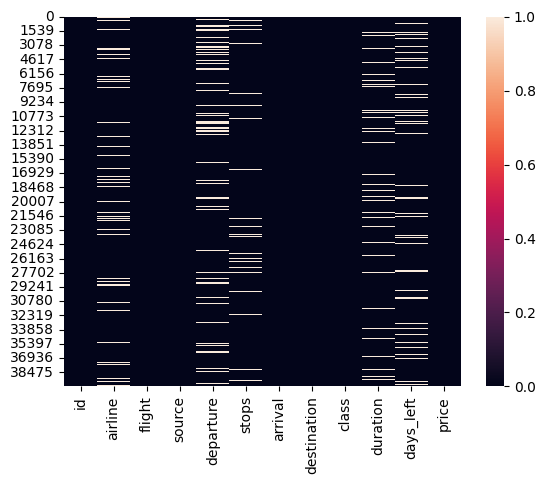

In [9]:
sns.heatmap(train_data.isna())

In [10]:
test_data.head()

,id,airline,flight,source,departure,stops,arrival,destination,class,duration,days_left
0,0,Vistara,UK-816,Bangalore,Morning,zero,Afternoon,Delhi,Economy,2.67,18.0
1,1,Air_India,AI-440,Chennai,Early_Morning,zero,Morning,Delhi,Economy,NaN,5.0
2,2,SpiceJet,SG-8938,Delhi,Evening,one,Evening,Bangalore,Economy,NaN,44.0
3,3,Vistara,UK-838,Chennai,Night,one,Evening,Kolkata,Business,21.00,26.0
4,4,Air_India,AI-429,Delhi,Morning,one,Evening,Mumbai,Business,7.25,22.0


<Axes: >

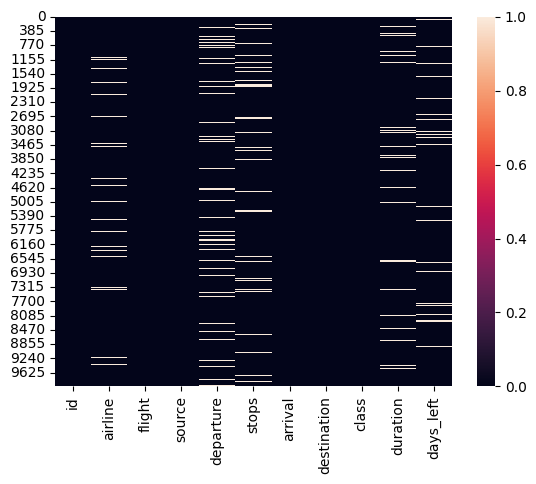

In [11]:
sns.heatmap(test_data.isna())

In [6]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           10000 non-null  int64  
 1   airline      9452 non-null   object 
 2   flight       10000 non-null  object 
 3   source       10000 non-null  object 
 4   departure    9080 non-null   object 
 5   stops        9349 non-null   object 
 6   arrival      10000 non-null  object 
 7   destination  10000 non-null  object 
 8   class        10000 non-null  object 
 9   duration     9418 non-null   float64
 10  days_left    9304 non-null   float64
dtypes: float64(2), int64(1), object(8)
memory usage: 859.5+ KB


In [26]:
train_data.isnull().sum()

airline        4613
flight            0
source            0
departure      4792
stops          2319
arrival           0
destination       0
class             0
duration       3013
days_left      4438
price             0
dtype: int64

In [13]:
test_data.isnull().sum()

id               0
airline        548
flight           0
source           0
departure      920
stops          651
arrival          0
destination      0
class            0
duration       582
days_left      696
dtype: int64

In [35]:
X_data=train_data.drop(columns=['id','flight','price'],axis=1)
y_data=train_data['price']
X_data.head()

,airline,source,departure,stops,arrival,destination,class,duration,days_left
0,Vistara,Mumbai,Early_Morning,one,Night,Chennai,Business,NaN,40.0
1,Air_India,Chennai,Evening,one,Morning,Mumbai,Economy,16.08,26.0
2,SpiceJet,Delhi,Early_Morning,zero,Morning,Chennai,Economy,2.92,25.0
3,NaN,Hyderabad,Early_Morning,zero,Morning,Bangalore,Economy,1.50,22.0
4,Air_India,Chennai,Early_Morning,one,Morning,Bangalore,Economy,4.83,20.0


In [37]:
cats_columns=X_data.select_dtypes(include=['object']).columns.tolist()
cats_columns

['airline', 'source', 'departure', 'stops', 'arrival', 'destination', 'class']

In [38]:
nums_columns=X_data.select_dtypes(include=['number']).columns.tolist()
nums_columns
cats_columns

['duration', 'days_left']

In [36]:
y_data.head()

0    64173
1     4357
2     3251
3     1776
4     3584
Name: price, dtype: int64

In [23]:
column_name=train_data.columns
column_name

Index(['airline', 'flight', 'source', 'departure', 'stops', 'arrival',
       'destination', 'class', 'duration', 'days_left', 'price'],
      dtype='object')

In [39]:
test_data_new=test_data.drop(columns=['id','flight'],axis=1)
test_data_new.head()

,airline,source,departure,stops,arrival,destination,class,duration,days_left
0,Vistara,Bangalore,Morning,zero,Afternoon,Delhi,Economy,2.67,18.0
1,Air_India,Chennai,Early_Morning,zero,Morning,Delhi,Economy,NaN,5.0
2,SpiceJet,Delhi,Evening,one,Evening,Bangalore,Economy,NaN,44.0
3,Vistara,Chennai,Night,one,Evening,Kolkata,Business,21.00,26.0
4,Air_India,Delhi,Morning,one,Evening,Mumbai,Business,7.25,22.0


In [41]:
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import (StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler, LabelEncoder, 
OrdinalEncoder, OneHotEncoder)
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, make_column_selector, make_column_transformer

In [50]:
cat_pipe=Pipeline(steps=[
    ("imputer",SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(handle_unknown='ignore', drop='first'))])
    
num_pipe=Pipeline(steps=[
    ("imputer",SimpleImputer(strategy='mean')),
    ('scaler',StandardScaler())
])


transformer=[('cats',cat_pipe,cats_columns),
             ('num',num_pipe,nums_columns)]

preprocesor=ColumnTransformer(transformer,remainder='passthrough')
preprocesor

ColumnTransformer(remainder='passthrough',
                  transformers=[('cats',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'))]),
                                 ['airline', 'source', 'departure', 'stops',
                                  'arrival', 'destination', 'class']),
                                ('num',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['duration', 'days_left'])])

In [51]:
X_train_processed=preprocesor.fit_transform(X_data)
X_test_processed=preprocesor.transform(test_data_new)

In [59]:
# ohe_columns=
preprocesor.named_transformers_['cats']\
.named_steps['encoder']\
.get_feature_names_out(cats_columns)

array(['airline_Air_India', 'airline_GO_FIRST', 'airline_Indigo',
       'airline_SpiceJet', 'airline_Vistara', 'source_Chennai',
       'source_Delhi', 'source_Hyderabad', 'source_Kolkata',
       'source_Mumbai', 'departure_Early_Morning', 'departure_Evening',
       'departure_Late_Night', 'departure_Morning', 'departure_Night',
       'stops_two_or_more', 'stops_zero', 'arrival_Early_Morning',
       'arrival_Evening', 'arrival_Late_Night', 'arrival_Morning',
       'arrival_Night', 'destination_Chennai', 'destination_Delhi',
       'destination_Hyderabad', 'destination_Kolkata',
       'destination_Mumbai', 'class_Economy'], dtype=object)

In [62]:
ohe_columns = preprocesor.named_transformers_['cats']\
                          .named_steps['encoder']\
                          .get_feature_names_out(cats_columns)
final_columns=nums_columns+list(ohe_columns)
final_columns

['duration',
 'days_left',
 'airline_Air_India',
 'airline_GO_FIRST',
 'airline_Indigo',
 'airline_SpiceJet',
 'airline_Vistara',
 'source_Chennai',
 'source_Delhi',
 'source_Hyderabad',
 'source_Kolkata',
 'source_Mumbai',
 'departure_Early_Morning',
 'departure_Evening',
 'departure_Late_Night',
 'departure_Morning',
 'departure_Night',
 'stops_two_or_more',
 'stops_zero',
 'arrival_Early_Morning',
 'arrival_Evening',
 'arrival_Late_Night',
 'arrival_Morning',
 'arrival_Night',
 'destination_Chennai',
 'destination_Delhi',
 'destination_Hyderabad',
 'destination_Kolkata',
 'destination_Mumbai',
 'class_Economy']

In [63]:
x_train_df=pd.DataFrame(X_train_processed.toarray() if hasattr(X_train_processed, "toarray") else X_train_processed, 
                        columns=final_columns)
x_test_df=pd.DataFrame(X_test_processed.toarray() if hasattr(X_test_processed, "toarray") else X_test_processed, 
                        columns=final_columns)

In [65]:
print("Train Shape :", x_train_df.shape)
print("Test Shape :", x_test_df.shape)

x_train_df.head()

Train Shape : (40000, 30)
Test Shape : (10000, 30)


,duration,days_left,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,source_Chennai,source_Delhi,source_Hyderabad,...,arrival_Evening,arrival_Late_Night,arrival_Morning,arrival_Night,destination_Chennai,destination_Delhi,destination_Hyderabad,destination_Kolkata,destination_Mumbai,class_Economy
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.086786
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.596327,-0.015586
2,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,-1.329050,-0.094327
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.536804,-0.330549
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.049607,-0.488031


In [67]:
x_test_df.head()

,duration,days_left,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,source_Chennai,source_Delhi,source_Hyderabad,...,arrival_Evening,arrival_Late_Night,arrival_Morning,arrival_Night,destination_Chennai,destination_Delhi,destination_Hyderabad,destination_Kolkata,destination_Mumbai,class_Economy
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,-1.365626,-0.645513
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.000000,-1.669144
2,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000,1.401750
3,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.316149,-0.015586
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.695548,-0.330549


In [69]:
y_data.shape

(40000,)

In [70]:
new_train_data=pd.concat([x_train_df,y_data], axis=1)
new_train_data

,duration,days_left,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,source_Chennai,source_Delhi,source_Hyderabad,...,arrival_Late_Night,arrival_Morning,arrival_Night,destination_Chennai,destination_Delhi,destination_Hyderabad,destination_Kolkata,destination_Mumbai,class_Economy,price
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.086786e+00,64173
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.596327,-1.558565e-02,4357
2,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,-1.329050,-9.432652e-02,3251
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.536804,-3.305491e-01,1776
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.049607,-4.880309e-01,3584
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.352726,1.323009e+00,6450
39996,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.303717,-1.117958e+00,64831
39997,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.340293,2.797438e-16,8062
39998,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.853090,-1.747885e+00,84557


In [71]:
from sklearn.model_selection import (train_test_split, KFold, cross_val_score, cross_validate, cross_val_predict, StratifiedKFold, StratifiedShuffleSplit, GridSearchCV, RandomizedSearchCV)

In [73]:
X_train, X_test, y_train, y_test=train_test_split(x_train_df, y_data, test_size=0.20, random_state=29)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)
print(x_test_df.shape)

(32000, 30)
(8000, 30)
(32000,)
(8000,)
(10000, 30)


In [74]:
#Linear model
from sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor, HuberRegressor)

#tree model
from sklearn.tree import DecisionTreeRegressor

#Ensemble model
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, ExtraTreesRegressor, BaggingRegressor, VotingRegressor, HistGradientBoostingRegressor)

#SVM
from sklearn.svm import SVR

#KNN
from sklearn.neighbors import KNeighborsRegressor

#Base line model
from sklearn.dummy import DummyRegressor

#High-performance gradient boosting frameworks
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# METRICS for Regression
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error)


In [77]:
models={
    # "Linear Regression": LinearRegression(),
    # "Ridge Reg" : Ridge(),
    # "Lasso Reg" : Lasso(),
    # "Decision Tree" : DecisionTreeRegressor(),
    "Random Forest" : RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42),
    'XGB': XGBRegressor(),
    'LGBM': LGBMRegressor()
}

# results=[]
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred=model.predict(X_test)
    mse_score=mean_squared_error(y_test, y_pred)
    score_r2=r2_score(y_test, y_pred)
    print("="*60)
    print("Model name :", name)
    print(f" MSE Score: {mse_score}")
    print(f" R2 Score: {score_r2}")
    # results.append({
    #     'Model': name,'MSE': mse_score, 'R2': r2_score})


 MSE Score: 15848512.400760515
 R2 Score: 0.9697824165001876
 MSE Score: 28594443.058142718
 R2 Score: 0.9454803738741691
 MSE Score: 18077340.0
 R2 Score: 0.9655328392982483
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005160 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 362
[LightGBM] [Info] Number of data points in the train set: 32000, number of used features: 30
[LightGBM] [Info] Start training from score 20699.751250
 MSE Score: 20155549.666739713
 R2 Score: 0.9615703991871125


In [ ]:
best_model=RandomForestRegressor(n_estimators=200)
best_model.fit(X_train,y_train)
test_pred=best_model.predict(x_test_df)
test_pred=np.clip(test_pred, 0, None)

In [ ]:
submission = pd.DataFrame({
    "id": range(x_test_df.shape[0]),
    "price": test_pred
})
submission.to_csv("submission.csv", index=False)
submission

In [83]:
# =========================================================
# AIRLINE PRICE PREDICTION - OPTIMIZED VERSION
# =========================================================

# =========================================================
# IMPORT LIBRARIES
# =========================================================

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Model Selection
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score
)

# Metrics
from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

# Models
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# =========================================================
# LOAD DATA
# =========================================================

train_data = pd.read_csv(
    "/kaggle/input/competitions/mlp-term-2-2025-kaggle-assignment-1/train.csv"
)

test_data = pd.read_csv(
    "/kaggle/input/competitions/mlp-term-2-2025-kaggle-assignment-1/test.csv"
)

sample_submission = pd.read_csv(
    "/kaggle/input/competitions/mlp-term-2-2025-kaggle-assignment-1/sample_submission.csv"
)

print("=" * 60)
print("Train Shape :", train_data.shape)
print("Test Shape :", test_data.shape)

# =========================================================
# BASIC DATA CHECK
# =========================================================

print("=" * 60)
print(train_data.head())

print("=" * 60)
print(train_data.info())

# =========================================================
# FEATURE ENGINEERING
# =========================================================

def feature_engineering(df):

    df = df.copy()

    # ---------------------------------------------
    # CONVERT STOPS TO NUMERIC
    # ---------------------------------------------

    if 'stops' in df.columns:

        df['stops'] = (
            df['stops']
            .astype(str)
            .str.extract('(\d+)')[0]
        )

        df['stops'] = pd.to_numeric(
            df['stops'],
            errors='coerce'
        )

        # Fill nonstop as 0
        df['stops'] = df['stops'].fillna(0)

    # ---------------------------------------------
    # CONVERT DURATION TO NUMERIC
    # ---------------------------------------------

    if 'duration' in df.columns:

        df['duration'] = pd.to_numeric(
            df['duration'],
            errors='coerce'
        )

    # ---------------------------------------------
    # EXTRA FEATURES
    # ---------------------------------------------

    if 'duration' in df.columns:

        df['duration_hour'] = df['duration'] / 60

    if 'stops' in df.columns and 'duration' in df.columns:

        df['stops_duration'] = (
            df['stops'] * df['duration']
        )

    # ---------------------------------------------
    # OUTLIER CAPPING
    # ---------------------------------------------

    if 'duration' in df.columns:

        q1 = df['duration'].quantile(0.01)
        q3 = df['duration'].quantile(0.99)

        df['duration'] = df['duration'].clip(q1, q3)

    return df

# =========================================================
# APPLY FEATURE ENGINEERING
# =========================================================

train_data = feature_engineering(train_data)
test_data = feature_engineering(test_data)

# =========================================================
# FEATURES & TARGET
# =========================================================

X_data = train_data.drop(
    columns=['id', 'flight', 'price'],
    axis=1
)

y_data = train_data['price']

# IMPORTANT:
# LOG TRANSFORMATION REMOVED
# because your previous score dropped.
# We will use original target.

test_data_new = test_data.drop(
    columns=['id', 'flight'],
    axis=1
)

# =========================================================
# IDENTIFY COLUMN TYPES
# =========================================================

cats_columns = X_data.select_dtypes(
    include=['object']
).columns.tolist()

nums_columns = X_data.select_dtypes(
    include=['number']
).columns.tolist()

print("=" * 60)
print("Categorical Columns :", cats_columns)
print("Numerical Columns :", nums_columns)

# =========================================================
# NUMERICAL PIPELINE
# =========================================================

num_pipe = Pipeline(steps=[

    ('imputer', SimpleImputer(strategy='median')),

    ('scaler', StandardScaler())
])

# =========================================================
# CATEGORICAL PIPELINE
# =========================================================

cat_pipe = Pipeline(steps=[

    ('imputer', SimpleImputer(strategy='most_frequent')),

    ('encoder', OneHotEncoder(
        handle_unknown='ignore'
    ))
])

# =========================================================
# COLUMN TRANSFORMER
# =========================================================

preprocessor = ColumnTransformer(

    transformers=[

        ('num', num_pipe, nums_columns),

        ('cat', cat_pipe, cats_columns)
    ]
)

# =========================================================
# TRANSFORM DATA
# =========================================================

X_processed = preprocessor.fit_transform(X_data)

X_test_processed = preprocessor.transform(test_data_new)

print("=" * 60)
print("Processed Train Shape :", X_processed.shape)
print("Processed Test Shape :", X_test_processed.shape)

# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train, X_valid, y_train, y_valid = train_test_split(

    X_processed,
    y_data,

    test_size=0.20,
    random_state=42
)

# =========================================================
# MODELS
# =========================================================

models = {

    "XGBoost": XGBRegressor(

        n_estimators=1800,
        learning_rate=0.03,
        max_depth=8,

        min_child_weight=2,

        subsample=0.90,
        colsample_bytree=0.90,

        gamma=0.1,

        reg_alpha=0.1,
        reg_lambda=1,

        objective='reg:squarederror',

        random_state=42,
        tree_method='hist',

        n_jobs=-1
    ),

    "LightGBM": LGBMRegressor(

        n_estimators=1800,
        learning_rate=0.03,
        max_depth=8,

        num_leaves=31,

        subsample=0.90,
        colsample_bytree=0.90,

        random_state=42
    ),

    "CatBoost": CatBoostRegressor(

        iterations=1800,
        learning_rate=0.03,
        depth=8,

        loss_function='RMSE',

        verbose=0,
        random_state=42
    )
}

# =========================================================
# MODEL TRAINING & EVALUATION
# =========================================================

results = []

for name, model in models.items():

    print("\n" + "=" * 60)
    print("Training :", name)

    model.fit(X_train, y_train)

    pred = model.predict(X_valid)

    mse = mean_squared_error(
        y_valid,
        pred
    )

    r2 = r2_score(
        y_valid,
        pred
    )

    print("MSE :", mse)
    print("R2 Score :", r2)

    results.append([name, mse, r2])

# =========================================================
# RESULTS DATAFRAME
# =========================================================

results_df = pd.DataFrame(

    results,
    columns=['Model', 'MSE', 'R2']
)

results_df = results_df.sort_values(
    by='R2',
    ascending=False
)

print("\n" + "=" * 60)
print("FINAL RESULTS")
print(results_df)

# =========================================================
# BEST MODEL
# =========================================================

best_model = XGBRegressor(

    n_estimators=1800,
    learning_rate=0.03,
    max_depth=8,

    min_child_weight=2,

    subsample=0.90,
    colsample_bytree=0.90,

    gamma=0.1,

    reg_alpha=0.1,
    reg_lambda=1,

    objective='reg:squarederror',

    random_state=42,
    tree_method='hist',

    n_jobs=-1
)

# =========================================================
# TRAIN FINAL MODEL
# =========================================================

best_model.fit(
    X_processed,
    y_data
)

# =========================================================
# TEST PREDICTION
# =========================================================

test_prediction = best_model.predict(
    X_test_processed
)

# =========================================================
# SUBMISSION FILE
# =========================================================

submission = pd.DataFrame({

    'id': test_data['id'],
    'price': test_prediction
})

submission.to_csv(
    "submission.csv",
    index=False
)

print("\n" + "=" * 60)
print("SUBMISSION FILE CREATED")
print(submission.head())

Train Shape : (40000, 12)
Test Shape : (10000, 11)
   id    airline    flight     source      departure stops  arrival  \
0   0    Vistara    UK-930     Mumbai  Early_Morning   one    Night   
1   1  Air_India    AI-539    Chennai        Evening   one  Morning   
2   2   SpiceJet   SG-8107      Delhi  Early_Morning  zero  Morning   
3   3        NaN  0.00E+00  Hyderabad  Early_Morning  zero  Morning   
4   4  Air_India    AI-569    Chennai  Early_Morning   one  Morning   

  destination     class  duration  days_left  price  
0     Chennai  Business       NaN       40.0  64173  
1      Mumbai   Economy     16.08       26.0   4357  
2     Chennai   Economy      2.92       25.0   3251  
3   Bangalore   Economy      1.50       22.0   1776  
4   Bangalore   Economy      4.83       20.0   3584  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   

In [84]:
# =========================================================
# AIRLINE PRICE PREDICTION - OPTIMIZED VERSION
# =========================================================

# =========================================================
# IMPORT LIBRARIES
# =========================================================

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Model Selection
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score
)

# Metrics
from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

# Models
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# =========================================================
# LOAD DATA
# =========================================================

train_data = pd.read_csv(
    "/kaggle/input/competitions/mlp-term-2-2025-kaggle-assignment-1/train.csv"
)

test_data = pd.read_csv(
    "/kaggle/input/competitions/mlp-term-2-2025-kaggle-assignment-1/test.csv"
)

sample_submission = pd.read_csv(
    "/kaggle/input/competitions/mlp-term-2-2025-kaggle-assignment-1/sample_submission.csv"
)

print("=" * 60)
print("Train Shape :", train_data.shape)
print("Test Shape :", test_data.shape)

# =========================================================
# BASIC DATA CHECK
# =========================================================

print("=" * 60)
print(train_data.head())

print("=" * 60)
print(train_data.info())

# =========================================================
# FEATURE ENGINEERING
# =========================================================

def feature_engineering(df):

    df = df.copy()

    # ---------------------------------------------
    # CONVERT STOPS TO NUMERIC
    # ---------------------------------------------

    if 'stops' in df.columns:

        df['stops'] = (
            df['stops']
            .astype(str)
            .str.extract('(\d+)')[0]
        )

        df['stops'] = pd.to_numeric(
            df['stops'],
            errors='coerce'
        )

        # Fill nonstop as 0
        df['stops'] = df['stops'].fillna(0)

    # ---------------------------------------------
    # CONVERT DURATION TO NUMERIC
    # ---------------------------------------------

    if 'duration' in df.columns:

        df['duration'] = pd.to_numeric(
            df['duration'],
            errors='coerce'
        )

    # ---------------------------------------------
    # EXTRA FEATURES
    # ---------------------------------------------

    if 'duration' in df.columns:

        df['duration_hour'] = df['duration'] / 60

    if 'stops' in df.columns and 'duration' in df.columns:

        df['stops_duration'] = (
            df['stops'] * df['duration']
        )

    # ---------------------------------------------
    # OUTLIER CAPPING
    # ---------------------------------------------

    if 'duration' in df.columns:

        q1 = df['duration'].quantile(0.01)
        q3 = df['duration'].quantile(0.99)

        df['duration'] = df['duration'].clip(q1, q3)

    return df

# =========================================================
# APPLY FEATURE ENGINEERING
# =========================================================

train_data = feature_engineering(train_data)
test_data = feature_engineering(test_data)

# =========================================================
# FEATURES & TARGET
# =========================================================

X_data = train_data.drop(
    columns=['id', 'flight', 'price'],
    axis=1
)

y_data = train_data['price']

# IMPORTANT:
# LOG TRANSFORMATION REMOVED
# because your previous score dropped.
# We will use original target.

test_data_new = test_data.drop(
    columns=['id', 'flight'],
    axis=1
)

# =========================================================
# IDENTIFY COLUMN TYPES
# =========================================================

cats_columns = X_data.select_dtypes(
    include=['object']
).columns.tolist()

nums_columns = X_data.select_dtypes(
    include=['number']
).columns.tolist()

print("=" * 60)
print("Categorical Columns :", cats_columns)
print("Numerical Columns :", nums_columns)

# =========================================================
# NUMERICAL PIPELINE
# =========================================================

num_pipe = Pipeline(steps=[

    ('imputer', SimpleImputer(strategy='median')),

    ('scaler', StandardScaler())
])

# =========================================================
# CATEGORICAL PIPELINE
# =========================================================

cat_pipe = Pipeline(steps=[

    ('imputer', SimpleImputer(strategy='most_frequent')),

    ('encoder', OneHotEncoder(
        handle_unknown='ignore'
    ))
])

# =========================================================
# COLUMN TRANSFORMER
# =========================================================

preprocessor = ColumnTransformer(

    transformers=[

        ('num', num_pipe, nums_columns),

        ('cat', cat_pipe, cats_columns)
    ]
)

# =========================================================
# TRANSFORM DATA
# =========================================================

X_processed = preprocessor.fit_transform(X_data)

X_test_processed = preprocessor.transform(test_data_new)

print("=" * 60)
print("Processed Train Shape :", X_processed.shape)
print("Processed Test Shape :", X_test_processed.shape)

# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train, X_valid, y_train, y_valid = train_test_split(

    X_processed,
    y_data,

    test_size=0.20,
    random_state=42
)

# =========================================================
# MODELS
# =========================================================

models = {

    "XGBoost": XGBRegressor(

        n_estimators=1800,
        learning_rate=0.03,
        max_depth=8,

        min_child_weight=2,

        subsample=0.90,
        colsample_bytree=0.90,

        gamma=0.1,

        reg_alpha=0.1,
        reg_lambda=1,

        objective='reg:squarederror',

        random_state=42,
        tree_method='hist',

        n_jobs=-1
    ),

    "LightGBM": LGBMRegressor(

        n_estimators=1800,
        learning_rate=0.03,
        max_depth=8,

        num_leaves=31,

        subsample=0.90,
        colsample_bytree=0.90,

        random_state=42
    ),

    "CatBoost": CatBoostRegressor(

        iterations=1800,
        learning_rate=0.03,
        depth=8,

        loss_function='RMSE',

        verbose=0,
        random_state=42
    )
}

# =========================================================
# MODEL TRAINING & EVALUATION
# =========================================================

results = []

for name, model in models.items():

    print("\n" + "=" * 60)
    print("Training :", name)

    model.fit(X_train, y_train)

    pred = model.predict(X_valid)

    mse = mean_squared_error(
        y_valid,
        pred
    )

    r2 = r2_score(
        y_valid,
        pred
    )

    print("MSE :", mse)
    print("R2 Score :", r2)

    results.append([name, mse, r2])

# =========================================================
# RESULTS DATAFRAME
# =========================================================

results_df = pd.DataFrame(

    results,
    columns=['Model', 'MSE', 'R2']
)

results_df = results_df.sort_values(
    by='R2',
    ascending=False
)

print("\n" + "=" * 60)
print("FINAL RESULTS")
print(results_df)

# =========================================================
# TRAIN ALL MODELS ON FULL DATA
# =========================================================

xgb_model = XGBRegressor(

    n_estimators=1800,
    learning_rate=0.03,
    max_depth=8,

    min_child_weight=2,

    subsample=0.90,
    colsample_bytree=0.90,

    gamma=0.1,

    reg_alpha=0.1,
    reg_lambda=1,

    objective='reg:squarederror',

    random_state=42,
    tree_method='hist',

    n_jobs=-1
)

cat_model = CatBoostRegressor(

    iterations=1800,
    learning_rate=0.03,
    depth=8,

    loss_function='RMSE',

    verbose=0,
    random_state=42
)

lgbm_model = LGBMRegressor(

    n_estimators=1800,
    learning_rate=0.03,
    max_depth=8,

    num_leaves=31,

    subsample=0.90,
    colsample_bytree=0.90,

    random_state=42
)

# =========================================================
# FIT MODELS
# =========================================================

xgb_model.fit(X_processed, y_data)

cat_model.fit(X_processed, y_data)

lgbm_model.fit(X_processed, y_data)

# =========================================================
# PREDICTIONS
# =========================================================

xgb_pred = xgb_model.predict(X_test_processed)

cat_pred = cat_model.predict(X_test_processed)

lgbm_pred = lgbm_model.predict(X_test_processed)

# =========================================================
# WEIGHTED BLENDING
# =========================================================

final_prediction = (

    0.60 * xgb_pred +

    0.25 * cat_pred +

    0.15 * lgbm_pred
)

# =========================================================
# SUBMISSION FILE
# =========================================================

submission = pd.DataFrame({

    'id': test_data['id'],
    'price': final_prediction
})

submission.to_csv(
    "submission.csv",
    index=False
)

print("Submission File Created Successfully")
print(submission.head())


Train Shape : (40000, 12)
Test Shape : (10000, 11)
   id    airline    flight     source      departure stops  arrival  \
0   0    Vistara    UK-930     Mumbai  Early_Morning   one    Night   
1   1  Air_India    AI-539    Chennai        Evening   one  Morning   
2   2   SpiceJet   SG-8107      Delhi  Early_Morning  zero  Morning   
3   3        NaN  0.00E+00  Hyderabad  Early_Morning  zero  Morning   
4   4  Air_India    AI-569    Chennai  Early_Morning   one  Morning   

  destination     class  duration  days_left  price  
0     Chennai  Business       NaN       40.0  64173  
1      Mumbai   Economy     16.08       26.0   4357  
2     Chennai   Economy      2.92       25.0   3251  
3   Bangalore   Economy      1.50       22.0   1776  
4   Bangalore   Economy      4.83       20.0   3584  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   

In [82]:
# # =========================================================
# # IMPORT LIBRARIES
# # =========================================================

# import numpy as np
# import pandas as pd
# import warnings
# warnings.filterwarnings("ignore")

# # Visualization
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Preprocessing
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import OneHotEncoder, RobustScaler
# from sklearn.pipeline import Pipeline
# from sklearn.compose import ColumnTransformer

# # Model Selection
# from sklearn.model_selection import (
#     train_test_split
# )

# # Metrics
# from sklearn.metrics import (
#     mean_squared_error,
#     r2_score
# )

# # Models
# from xgboost import XGBRegressor
# from lightgbm import LGBMRegressor
# from catboost import CatBoostRegressor

# # =========================================================
# # LOAD DATA
# # =========================================================

# train_data = pd.read_csv(
#     "/kaggle/input/competitions/mlp-term-2-2025-kaggle-assignment-1/train.csv"
# )

# test_data = pd.read_csv(
#     "/kaggle/input/competitions/mlp-term-2-2025-kaggle-assignment-1/test.csv"
# )

# sample_data = pd.read_csv(
#     "/kaggle/input/competitions/mlp-term-2-2025-kaggle-assignment-1/sample_submission.csv"
# )

# print("=" * 60)
# print("Train Shape :", train_data.shape)
# print("Test Shape :", test_data.shape)

# # =========================================================
# # FEATURE ENGINEERING FUNCTION
# # =========================================================

# def feature_engineering(df):

#     df = df.copy()

#     # -----------------------------------------
#     # CONVERT STOPS TO NUMERIC
#     # -----------------------------------------

#     if 'stops' in df.columns:

#         df['stops'] = (
#             df['stops']
#             .astype(str)
#             .str.extract('(\d+)')[0]
#         )

#         df['stops'] = pd.to_numeric(
#             df['stops'],
#             errors='coerce'
#         )

#     # -----------------------------------------
#     # CONVERT DURATION TO NUMERIC
#     # -----------------------------------------

#     if 'duration' in df.columns:

#         df['duration'] = pd.to_numeric(
#             df['duration'],
#             errors='coerce'
#         )

#         # Duration in hours
#         df['duration_hour'] = df['duration'] / 60

#     # -----------------------------------------
#     # INTERACTION FEATURE
#     # -----------------------------------------

#     if 'stops' in df.columns and 'duration' in df.columns:

#         df['stops_duration_interaction'] = (
#             df['stops'] * df['duration']
#         )

#     return df

# # =========================================================
# # APPLY FEATURE ENGINEERING
# # =========================================================

# train_data = feature_engineering(train_data)
# test_data = feature_engineering(test_data)

# # =========================================================
# # FEATURES & TARGET
# # =========================================================

# X_data = train_data.drop(
#     columns=['id', 'flight', 'price'],
#     axis=1
# )

# y_data = train_data['price']

# # LOG TRANSFORM TARGET
# y_log = np.log1p(y_data)

# test_data_new = test_data.drop(
#     columns=['id', 'flight'],
#     axis=1
# )

# # =========================================================
# # IDENTIFY COLUMNS
# # =========================================================

# cats_columns = X_data.select_dtypes(
#     include=['object']
# ).columns.tolist()

# nums_columns = X_data.select_dtypes(
#     include=['number']
# ).columns.tolist()

# print("=" * 60)
# print("Categorical Columns :", cats_columns)
# print("Numerical Columns :", nums_columns)

# # =========================================================
# # NUMERICAL PIPELINE
# # =========================================================

# num_pipe = Pipeline(steps=[

#     ('imputer', SimpleImputer(strategy='median')),

#     ('scaler', RobustScaler())
# ])

# # =========================================================
# # CATEGORICAL PIPELINE
# # =========================================================

# cat_pipe = Pipeline(steps=[

#     ('imputer', SimpleImputer(strategy='most_frequent')),

#     ('encoder', OneHotEncoder(
#         handle_unknown='ignore'
#     ))
# ])

# # =========================================================
# # COLUMN TRANSFORMER
# # =========================================================

# preprocessor = ColumnTransformer(

#     transformers=[

#         ('num', num_pipe, nums_columns),

#         ('cat', cat_pipe, cats_columns)
#     ]
# )

# # =========================================================
# # TRANSFORM DATA
# # =========================================================

# X_processed = preprocessor.fit_transform(X_data)

# X_test_processed = preprocessor.transform(test_data_new)

# print("=" * 60)
# print("Processed Train Shape :", X_processed.shape)
# print("Processed Test Shape :", X_test_processed.shape)

# # =========================================================
# # TRAIN TEST SPLIT
# # =========================================================

# X_train, X_valid, y_train, y_valid = train_test_split(

#     X_processed,
#     y_log,

#     test_size=0.20,
#     random_state=42
# )

# # =========================================================
# # MODELS
# # =========================================================

# models = {

#     "XGBoost": XGBRegressor(

#         n_estimators=2500,
#         learning_rate=0.01,
#         max_depth=8,
#         min_child_weight=2,
#         subsample=0.85,
#         colsample_bytree=0.85,
#         reg_alpha=0.1,
#         reg_lambda=1,

#         objective='reg:squarederror',
#         random_state=42,
#         tree_method='hist'
#     ),

#     "LightGBM": LGBMRegressor(

#         n_estimators=2500,
#         learning_rate=0.01,
#         max_depth=8,
#         num_leaves=31,
#         subsample=0.85,
#         colsample_bytree=0.85,

#         random_state=42
#     ),

#     "CatBoost": CatBoostRegressor(

#         iterations=2500,
#         learning_rate=0.01,
#         depth=8,

#         loss_function='RMSE',
#         verbose=0,
#         random_state=42
#     )
# }

# # =========================================================
# # TRAIN & EVALUATE MODELS
# # =========================================================

# results = []

# for name, model in models.items():

#     print("\n" + "=" * 60)
#     print("Training Model :", name)

#     # Train
#     model.fit(X_train, y_train)

#     # Predict
#     pred_log = model.predict(X_valid)

#     # Reverse log transform
#     pred = np.expm1(pred_log)

#     y_actual = np.expm1(y_valid)

#     # Metrics
#     mse = mean_squared_error(y_actual, pred)

#     r2 = r2_score(y_actual, pred)

#     print("MSE :", mse)
#     print("R2 Score :", r2)

#     # Save result
#     results.append([name, mse, r2])

# # =========================================================
# # RESULTS DATAFRAME
# # =========================================================

# results_df = pd.DataFrame(

#     results,
#     columns=['Model', 'MSE', 'R2']
# )

# results_df = results_df.sort_values(
#     by='R2',
#     ascending=False
# )

# print("\n" + "=" * 60)
# print("FINAL MODEL RESULTS")
# print(results_df)

# # =========================================================
# # BEST MODEL TRAINING
# # =========================================================

# best_model = CatBoostRegressor(

#     iterations=2500,
#     learning_rate=0.01,
#     depth=8,

#     loss_function='RMSE',
#     verbose=0,
#     random_state=42
# )

# best_model.fit(X_processed, y_log)

# # =========================================================
# # FINAL TEST PREDICTION
# # =========================================================

# test_pred_log = best_model.predict(
#     X_test_processed
# )

# final_predictions = np.expm1(test_pred_log)

# # =========================================================
# # CREATE SUBMISSION FILE
# # =========================================================

# submission = pd.DataFrame({

#     'id': test_data['id'],
#     'price': final_predictions
# })

# submission.to_csv(
#     "submission.csv",
#     index=False
# )

# print("\n" + "=" * 60)
# print("Submission File Created Successfully")
# print(submission.head())

Train Shape : (40000, 12)
Test Shape : (10000, 11)
Categorical Columns : ['airline', 'source', 'departure', 'arrival', 'destination', 'class']
Numerical Columns : ['stops', 'duration', 'days_left', 'duration_hour', 'stops_duration_interaction']
Processed Train Shape : (40000, 35)
Processed Test Shape : (10000, 35)

Training Model : XGBoost
MSE : 17294350.466114357
R2 Score : 0.9664805393900316

Training Model : LightGBM
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000540 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 623
[LightGBM] [Info] Number of data points in the train set: 32000, number of used features: 35
[LightGBM] [Info] Start training from score 9.320196
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] 

,id,price
0,0,4540.420000
1,1,13584.365000
2,2,6312.257000
3,3,59787.225000
4,4,46273.495000
...,...,...
9995,9995,4203.600000
9996,9996,6235.562726
9997,9997,76241.260000
9998,9998,49102.595000
